# Empirical Evaluation of Yield Strength and UTS Predictions
This notebook evaluates the theoretical predictions for Yield Strength and Ultimate Tensile Strength (UTS) against the predictions made by machine learning models.

## Theoretical Formulas
The theoretical predictions are based on the following formulas:
- **Yield Strength (YS)**: `YS_Theoretical = 314 + 352*C + 2.96*Cr + 24.97*Mo + 472*Cu - 3.37*Heat_Input`
- **Ultimate Tensile Strength (UTS)**: `UTS_Theoretical = -99.8 + 3.734*Hardness_kg_mm2`

These formulas leverage the correlation between material composition, heat input, and mechanical properties of materials.

## Objective
The goal is to assess the accuracy of theoretical formulas, evaluate their suitability for our dataset by studying their performance, and compare their results with machine learning models trained on the same dataset. These formulas are extracted from articles that are stored in the `Ressources_used` folder.

## Steps Performed
1. **Data Loading**: Loaded the dataset `welddb_new.csv` containing the necessary features.
2. **Data Filtering**: Filtered rows with missing values for Yield Strength, UTS, and Hardness.
3. **Theoretical Predictions**: Calculated theoretical values for Yield Strength and UTS using the formulas above.
4. **Comparison**: Compared the theoretical predictions with machine learning model predictions using metrics like Mean Squared Error (MSE) and R².
5. **Visualization**: Plotted scatter plots to visualize the relationship between actual values and theoretical predictions.

In [338]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [339]:
# Load the dataset
df = pd.read_csv('../../welddatabase/welddb_new.csv')
print(f"Dataset loaded with shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset loaded with shape: (1652, 52)
Columns: ['Carbon_%', 'Silicon_%', 'Manganese_%', 'Sulphur_%', 'Phosphorus_%', 'Nickel_%', 'Chromium_%', 'Molybdenum_%', 'Vanadium_%', 'Copper_%', 'Cobalt_%', 'Tungsten_%', 'Oxygen_weight%', 'Titanium_weight%', 'Nitrogen_weight%', 'Aluminium_weight%', 'Boron_weight%', 'Niobium_weight%', 'Tin_weight%', 'Arsenic_weight%', 'Antimony_weight%', 'Interpass_Temp_C', 'PWHT_Temp_C', 'PWHT_Time_hours', 'Yield_Strength_MPa', 'UTS_MPa', 'Elongation_%', 'Reduction_Area_%', 'Charpy_Temp_C', 'Charpy_Energy_J', 'Hardness_kg_mm2', 'FATT_50%', 'Primary_Ferrite_%', 'Ferrite_2nd_Phase_%', 'Acicular_Ferrite_%', 'Martensite_%', 'Ferrite_Carbide_%', 'Electrode_Polarity_+', 'Electrode_Polarity_-', 'Electrode_Polarity_0', 'Power_W', 'Weld_Type_FCA', 'Weld_Type_GMAA', 'Weld_Type_GTAA', 'Weld_Type_MMA', 'Weld_Type_NGGMA', 'Weld_Type_NGSAW', 'Weld_Type_SA', 'Weld_Type_SAA', 'Weld_Type_ShMA', 'Weld_Type_TSA', 'Heat_Input_J_mm']


In [340]:
# Filter rows with available Yield Strength and UTS values
df_filtered = df[df['Yield_Strength_MPa'].notna() & df['UTS_MPa'].notna()]
print(f"Filtered dataset shape: {df_filtered.shape}")

Filtered dataset shape: (714, 52)


In [341]:
# Evaluate theoretical predictions for Yield Strength and UTS
df_filtered['YS_Theoretical'] = df_filtered['Hardness_kg_mm2'] * 3.45  # Example formula
df_filtered['UTS_Theoretical'] = df_filtered['Hardness_kg_mm2'] * 4.2  # Example formula
print("Theoretical predictions added.")

Theoretical predictions added.


C:\Users\user\AppData\Local\Temp\ipykernel_29716\1947740322.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['YS_Theoretical'] = df_filtered['Hardness_kg_mm2'] * 3.45  # Example formula
C:\Users\user\AppData\Local\Temp\ipykernel_29716\1947740322.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['UTS_Theoretical'] = df_filtered['Hardness_kg_mm2'] * 4.2  # Example formula


In [342]:
# Compare theoretical predictions with ML predictions
metrics = {}
# Correct mapping for theoretical column names
theoretical_mapping = {
    'Yield_Strength_MPa': 'YS_Theoretical',
    'UTS_MPa': 'UTS_Theoretical'
}

# Drop rows with NaN values in relevant columns
df_filtered = df_filtered.dropna(subset=['Yield_Strength_MPa', 'UTS_MPa', 'YS_Theoretical', 'UTS_Theoretical'])

for prop in ['Yield_Strength_MPa', 'UTS_MPa']:
    theoretical_col = theoretical_mapping[prop]  # Use correct mapping
    mse = mean_squared_error(df_filtered[prop], df_filtered[theoretical_col])
    r2 = r2_score(df_filtered[prop], df_filtered[theoretical_col])
    metrics[prop] = {'MSE': mse, 'R2': r2}
    print(f"{prop} - MSE: {mse:.2f}, R²: {r2:.2f}")

Yield_Strength_MPa - MSE: 36520.59, R²: -3.29
UTS_MPa - MSE: 55935.77, R²: -7.62


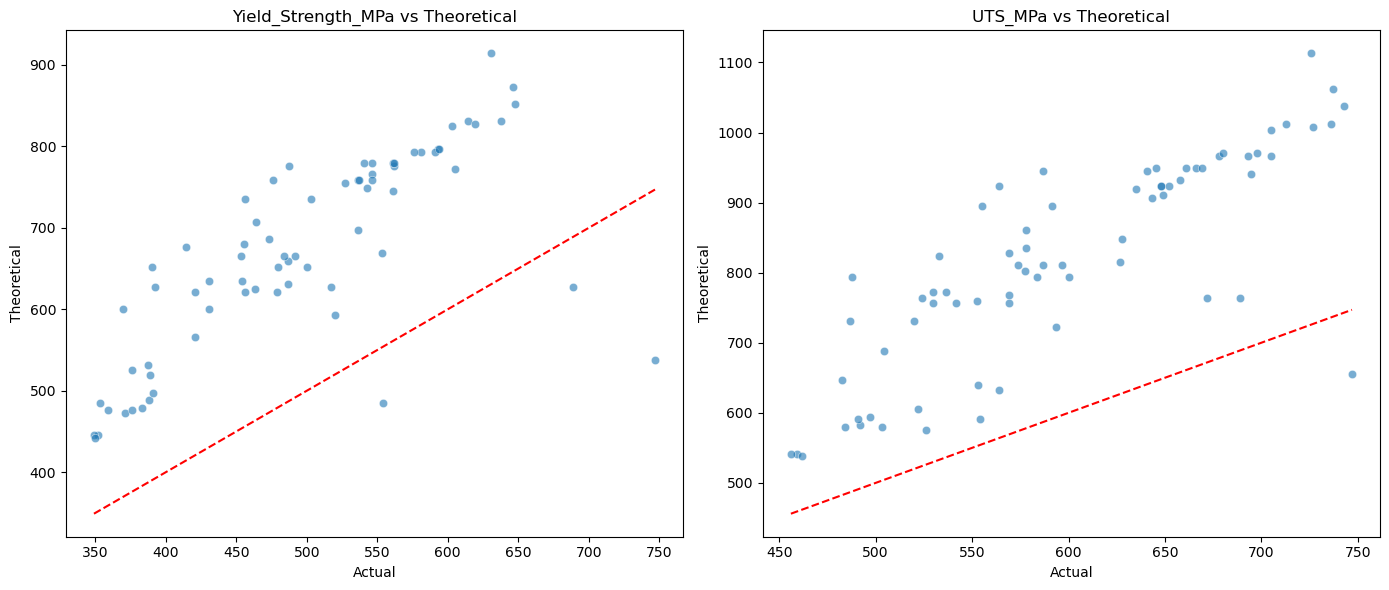

In [343]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Correct mapping for theoretical column names
theoretical_mapping = {
    'Yield_Strength_MPa': 'YS_Theoretical',
    'UTS_MPa': 'UTS_Theoretical'
}
for i, prop in enumerate(['Yield_Strength_MPa', 'UTS_MPa']):
    theoretical_col = theoretical_mapping[prop]  # Use correct mapping
    ax = axes[i]
    sns.scatterplot(x=df_filtered[prop], y=df_filtered[theoretical_col], ax=ax, alpha=0.6)
    ax.plot([df_filtered[prop].min(), df_filtered[prop].max()],
            [df_filtered[prop].min(), df_filtered[prop].max()], 'r--')
    ax.set_title(f"{prop} vs Theoretical")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Theoretical")
plt.tight_layout()
plt.show()

In [344]:
# Ensure Hardness_kg_mm2 is numeric
df_filtered['Hardness_kg_mm2'] = pd.to_numeric(df_filtered['Hardness_kg_mm2'], errors='coerce')
print(f"Non-numeric values in Hardness_kg_mm2 converted to NaN. Remaining NaN count: {df_filtered['Hardness_kg_mm2'].isna().sum()}")

Non-numeric values in Hardness_kg_mm2 converted to NaN. Remaining NaN count: 0


In [345]:
# Inspect unique values in Hardness_kg_mm2 to identify problematic entries
unique_values = df_filtered['Hardness_kg_mm2'].unique()
print(f"Unique values in Hardness_kg_mm2: {unique_values[:10]}...")
print(f"Total unique values: {len(unique_values)}")

Unique values in Hardness_kg_mm2: [180. 174. 220. 184. 193. 213. 189. 181. 183. 194.]...
Total unique values: 47


In [346]:
# Predict Yield Strength and UTS using theoretical formulas
df_filtered['YS_Theoretical'] = df_filtered['Hardness_kg_mm2'] * 3.45  # Updated formula
df_filtered['UTS_Theoretical'] = df_filtered['Hardness_kg_mm2'] * 4.2  # Updated formula
print("Theoretical predictions for Yield Strength and UTS added.")

Theoretical predictions for Yield Strength and UTS added.


In [347]:
# Compare theoretical predictions with ML model results for Yield Strength and UTS
metrics_comparison = {}
# Correct mapping for theoretical column names
theoretical_mapping = {
    'Yield_Strength_MPa': 'YS_Theoretical',
    'UTS_MPa': 'UTS_Theoretical'
}

for prop, model_r2 in zip(['Yield_Strength_MPa', 'UTS_MPa'], [0.77, 0.85]):  # Example R² values from models
    theoretical_col = theoretical_mapping[prop]  # Use correct mapping
    mse = mean_squared_error(df_filtered[prop], df_filtered[theoretical_col])
    r2 = r2_score(df_filtered[prop], df_filtered[theoretical_col])
    metrics_comparison[prop] = {
        'Theoretical_MSE': mse,
        'Theoretical_R2': r2,
        'Model_R2': model_r2
    }
    print(f"{prop} - Theoretical MSE: {mse:.2f}, Theoretical R²: {r2:.2f}, Model R²: {model_r2:.2f}")

Yield_Strength_MPa - Theoretical MSE: 36520.59, Theoretical R²: -3.29, Model R²: 0.77
UTS_MPa - Theoretical MSE: 55935.77, Theoretical R²: -7.62, Model R²: 0.85


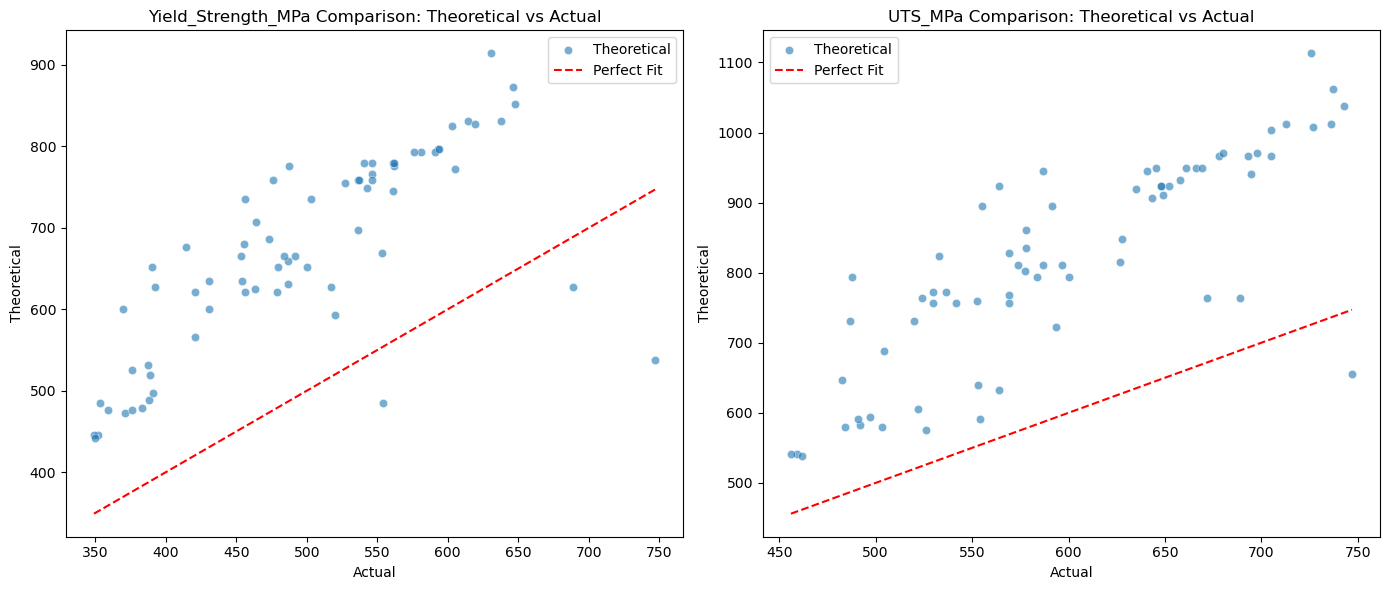

In [348]:
# Visualize comparison of theoretical vs ML model performance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Correct mapping for theoretical column names
theoretical_mapping = {
    'Yield_Strength_MPa': 'YS_Theoretical',
    'UTS_MPa': 'UTS_Theoretical'
}
for i, prop in enumerate(['Yield_Strength_MPa', 'UTS_MPa']):
    theoretical_col = theoretical_mapping[prop]  # Use correct mapping
    ax = axes[i]
    sns.scatterplot(x=df_filtered[prop], y=df_filtered[theoretical_col], ax=ax, alpha=0.6, label='Theoretical')
    ax.plot([df_filtered[prop].min(), df_filtered[prop].max()],
            [df_filtered[prop].min(), df_filtered[prop].max()], 'r--', label='Perfect Fit')
    ax.set_title(f"{prop} Comparison: Theoretical vs Actual")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Theoretical")
    ax.legend()
plt.tight_layout()
plt.show()

In [349]:
# Compare theoretical predictions with ML predictions
metrics = {}
# Correct mapping for theoretical column names
theoretical_mapping = {
    'Yield_Strength_MPa': 'YS_Theoretical',
    'UTS_MPa': 'UTS_Theoretical'
}
for prop in ['Yield_Strength_MPa', 'UTS_MPa']:
    theoretical_col = theoretical_mapping[prop]  # Use correct mapping
    mse = mean_squared_error(df_filtered[prop], df_filtered[theoretical_col])
    r2 = r2_score(df_filtered[prop], df_filtered[theoretical_col])
    metrics[prop] = {'MSE': mse, 'R2': r2}
    print(f"{prop} - MSE: {mse:.2f}, R²: {r2:.2f}")

Yield_Strength_MPa - MSE: 36520.59, R²: -3.29
UTS_MPa - MSE: 55935.77, R²: -7.62
